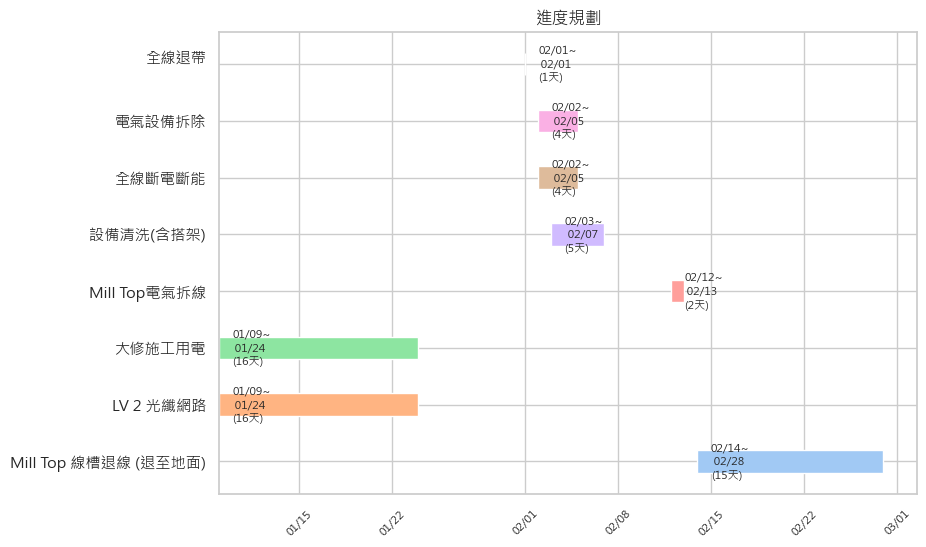

In [11]:
import pandas as pd 
import tkinter as tk
from tkinter import ttk
from tkinter import messagebox
import tkcalendar as tkc
from tkinter import filedialog
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import seaborn as sns

car1,car2,tree,file_path= None,None,None,None

def cal_date():  
    global cal1,cal2
    cal1 = tkc.Calendar(window, selectmode="day",year=2024,month=1,day=1)
    cal1.place(x=20, y=120)
    cal2 = tkc.Calendar(window, selectmode="day",year=2024,month=1,day=1)
    cal2.place(x=300, y=120)

def delete():
    
    tree.delete(tree.get_children())    

def save_file():
    global file_path
    file_path = filedialog.asksaveasfilename(defaultextension=".xlsx",filetypes=[("Excel files", "*.xlsx")])
    if file_path:
        messagebox.showinfo("儲存檔案","已儲存檔案")
    else:
        messagebox.showinfo("儲存檔案","未儲存檔案")
    return file_path
    
num = 1
def stage1(enter1,stage,cal1,cal2):
    global date_start,date_over,file_path,num

    date_start = cal1.get_date()
    date_over = cal2.get_date()
    date_start = pd.to_datetime(date_start).date()
    date_over = pd.to_datetime(date_over).date()

    s1 = enter1.get()
    
    if date_start > date_over:
        messagebox.showerror("錯誤","結束日期不可早於開始日期")
    else:
        tree.insert("", "end", values=[s1]+[stage]+[date_start]+[date_over])
        
        if not file_path:
           save_file()
           dic1 = {"編號":num,"工作名稱":s1,"階段名稱":stage,"開始日期":date_start,"結束日期":date_over}
           df1 = pd.DataFrame(dic1,index=[0])
           df1.to_excel(file_path, index=False)
        else:
            dic1 = {"編號":num,"工作名稱":s1,"階段名稱":stage,"開始日期":date_start,"結束日期":date_over}
            df1 = pd.DataFrame(dic1,index=[0])
            with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='overlay') as writer:
                  df1.to_excel(writer, index=False, header=False, startrow=len(pd.read_excel(file_path)) + 1)
    num += 1  
    

def stage_23(stage,cal1,cal2):
    global date_start,date_over,file_path
    date_start = cal1.get_date()
    date_over = cal2.get_date()
    date_start = pd.to_datetime(date_start).date()
    date_over = pd.to_datetime(date_over).date()
    s1 = enter1.get()
    if date_start > date_over:
        messagebox.showerror("錯誤","結束日期不可早於開始日期")
        
        
    else:
         tree.insert("", "end", values=[""]+[stage]+[date_start]+[date_over])
     
         dic2 = {"編號":"","工作名稱":s1,"階段名稱":stage,"開始日期":date_start,"結束日期":date_over}
         df2 = pd.DataFrame(dic2,index=[0])
         with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='overlay') as writer:
             df2.to_excel(writer, index=False, header=False, startrow=len(pd.read_excel(file_path)) + 1)
   

def draw():
    global file_path
    df = pd.read_excel(file_path)
    plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
    plt.rcParams["axes.unicode_minus"] = False
    df["開始日期"] = pd.to_datetime(df["開始日期"])
    df["結束日期"] = pd.to_datetime(df["結束日期"])
    period = df["結束日期"] - df["開始日期"]
    df.sort_values(['編號','開始日期'],ascending=False,inplace=True)

    sns.set_theme(palette='pastel')
    sns.set_style("whitegrid", {"font.sans-serif":['Microsoft JhengHei']})

    
    plt.figure(figsize=(15, 4))
    plt.title("進度規劃", fontsize=12)
    for _, i in df.iterrows():
        plt.barh(i["工作名稱"], period[_], left=i["開始日期"], height=0.4)
        date_range = f"{i['開始日期'].strftime('%m/%d')}~\n {i['結束日期'].strftime('%m/%d')}\n({period[_].days + 1}天)"
        plt.text(i["開始日期"] + pd.Timedelta(days=1), i["工作名稱"], date_range,fontsize=8, ha="left", va="center", bbox=dict(facecolor='none', edgecolor='none'))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    plt.xticks(rotation=45, fontsize=8)

    window2 = tk.Tk()
    window2.title("甘特圖")
    window2.geometry("900x600")
    canvas = FigureCanvasTkAgg(plt.gcf(), master=window2)
    canvas.draw()
    canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
    window2.mainloop()

def show():
    global tree,file_path
    text1 = tk.Label(window, text="請選擇開始日期", font=("微軟正黑體", 12),fg="blue",bg = "yellow")
    text1.place(x=20, y=80)
    text2 = tk.Label(window, text="請選擇結束日期", font=("微軟正黑體", 12),fg="blue",bg = "yellow")
    text2.place(x=300, y=80)
    cal_date()

    tree = ttk.Treeview(window, show="headings")
    tree.place(x=20, y=350, width=560, height=400)
    tree["columns"] = ["工作名稱","階段名稱","開始日期","結束日期"]
    for col in tree["columns"]:
        tree.heading(col,text=col,anchor="center")
        tree.column(col,width=120,anchor="center")
    file_path = None

    btn1 = tk.Button(window, text="第一階段日期", font=("微軟正黑體", 12),command=lambda:stage1(enter1,"第一階段日期",cal1,cal2))
    btn1.place(x=20, y=300)

    btn2 = tk.Button(window, text="第二階段日期", font=("微軟正黑體", 12),command=lambda:stage_23("第二階段日期",cal1,cal2))
    btn2.place(x=150, y=300)

    btn3 = tk.Button(window, text="第三階段日期", font=("微軟正黑體", 12),command=lambda:stage_23("第三階段日期",cal1,cal2))
    btn3.place(x=300, y=300)

    btn4 = tk.Button(window, text="清除", font=("微軟正黑體", 12),command=delete)
    btn4.place(x=450, y=300)

    btn5 = tk.Button(window, text="畫甘特圖", font=("微軟正黑體", 12),command=draw)
    btn5.place(x=450, y=750)

def open_file():
    global file_path
    file_path = filedialog.askopenfilename(filetypes=[("Excel files", "*.xlsx")])
    btn7 = tk.Button(window, text="畫甘特圖", font=("微軟正黑體", 12),command=draw)
    btn7.place(x=450, y=750)
    
    tree2 = ttk.Treeview(window, show="headings")
    tree2.place(x=20, y=350, width=560, height=400)
    tree2["columns"] = ["工作名稱","階段名稱","開始日期","結束日期"]
    for col in tree2["columns"]:
        tree2.heading(col,text=col,anchor="center")
        tree2.column(col,width=100,anchor="center")
    df = pd.read_excel(file_path)
    for i in range(len(df)):
        date_start = df.iloc[i,3].strftime('%Y-%m-%d')
        date_over = df.iloc[i,4].strftime('%Y-%m-%d')
        tree2.insert("", "end", values=[df.iloc[i,1]]+[df.iloc[i,2]]+[date_start]+[date_over])
    return file_path




window = tk.Tk()
window.title("甘特圖")
window.geometry("600x800")

text1 = tk.Label(window, text="請輸入工作名稱", font=("微軟正黑體", 12),fg="blue",bg = "yellow")
text1.place(x=20, y=40)
enter1 = tk.Entry(window, width=15,font=("微軟正黑體", 12))
enter1.place(x=160, y=40)
btn1 = tk.Button(window, text="選擇日期", font=("微軟正黑體", 12),command=show)
btn1.place(x=320, y=35)
btn6 = tk.Button(window,text='開啟檔案',font=("微軟正黑體", 12),command=open_file)
btn6.place(x=450, y=35)
window.mainloop()





In [41]:
import pandas as pd 
import tkinter as tk
from tkinter import ttk
from tkinter import messagebox
import tkcalendar as tkc
from tkinter import filedialog
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import seaborn as sns

car1,car2,tree,file_path= None,None,None,None

def cal_date():  
    global cal1,cal2
    cal1 = tkc.Calendar(window, selectmode="day",year=2024,month=1,day=1)
    cal1.place(x=20, y=120)
    cal2 = tkc.Calendar(window, selectmode="day",year=2024,month=1,day=1)
    cal2.place(x=300, y=120)

def delete():
    
    tree.delete(tree.get_children())    

def save_file():
    global file_path
    file_path = filedialog.asksaveasfilename(defaultextension=".xlsx",filetypes=[("Excel files", "*.xlsx")])
    if file_path:
        messagebox.showinfo("儲存檔案","已儲存檔案")
    else:
        messagebox.showinfo("儲存檔案","未儲存檔案")
    return file_path
    
num = 1
def stage1(enter1,stage,cal1,cal2):
    global date_start,date_over,file_path,num,tree

    date_start = cal1.get_date()
    date_over = cal2.get_date()
    date_start = pd.to_datetime(date_start).date()
    date_over = pd.to_datetime(date_over).date()

    s1 = enter1.get()
    
    if date_start > date_over:
        messagebox.showerror("錯誤","結束日期不可早於開始日期")
    else:
        tree.insert("", "end", values=[s1]+[stage]+[date_start]+[date_over])
        
        if not file_path:
           save_file()
           dic1 = {"編號":num,"工作名稱":s1,"階段名稱":stage,"開始日期":date_start,"結束日期":date_over}
           df1 = pd.DataFrame(dic1,index=[0])
           df1.to_excel(file_path, index=False)
        else:
            dic1 = {"編號":num,"工作名稱":s1,"階段名稱":stage,"開始日期":date_start,"結束日期":date_over}
            df1 = pd.DataFrame(dic1,index=[0])
            with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='overlay') as writer:
                  df1.to_excel(writer, index=False, header=False, startrow=len(pd.read_excel(file_path)) + 1)
    num += 1  
    

def stage_23(stage,cal1,cal2):
    global date_start,date_over,file_path
    date_start = cal1.get_date()
    date_over = cal2.get_date()
    date_start = pd.to_datetime(date_start).date()
    date_over = pd.to_datetime(date_over).date()
    s1 = enter1.get()
    if date_start > date_over:
        messagebox.showerror("錯誤","結束日期不可早於開始日期")
        
        
    else:
         tree.insert("", "end", values=[""]+[stage]+[date_start]+[date_over])
     
         dic2 = {"編號":"","工作名稱":s1,"階段名稱":stage,"開始日期":date_start,"結束日期":date_over}
         df2 = pd.DataFrame(dic2,index=[0])
         with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='overlay') as writer:
             df2.to_excel(writer, index=False, header=False, startrow=len(pd.read_excel(file_path)) + 1)
   

def draw():
    global file_path
    df = pd.read_excel(file_path)
    plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
    plt.rcParams["axes.unicode_minus"] = False
    df["開始日期"] = pd.to_datetime(df["開始日期"])
    df["結束日期"] = pd.to_datetime(df["結束日期"])
    period = df["結束日期"] - df["開始日期"]
    df.sort_values(['編號','開始日期'],ascending=False,inplace=True)

    sns.set_theme(palette='pastel')
    sns.set_style("whitegrid", {"font.sans-serif":['Microsoft JhengHei']})

    
    plt.figure(figsize=(15, 4))
    plt.title("進度規劃", fontsize=12)
    for _, i in df.iterrows():
        plt.barh(i["工作名稱"], period[_], left=i["開始日期"], height=0.4)
        date_range = f"{i['開始日期'].strftime('%m/%d')}~\n {i['結束日期'].strftime('%m/%d')}\n({period[_].days + 1}天)"
        plt.text(i["開始日期"] + pd.Timedelta(days=1), i["工作名稱"], date_range,fontsize=8, ha="left", va="center", bbox=dict(facecolor='none', edgecolor='none'))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    plt.xticks(rotation=45, fontsize=8)

    window2 = tk.Tk()
    window2.title("甘特圖")
    window2.geometry("900x600")
    canvas = FigureCanvasTkAgg(plt.gcf(), master=window2)
    canvas.draw()
    canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
    window2.mainloop()

def show():
    global tree,file_path
    text1 = tk.Label(window, text="請選擇開始日期", font=("微軟正黑體", 12),fg="blue",bg = "yellow")
    text1.place(x=20, y=80)
    text2 = tk.Label(window, text="請選擇結束日期", font=("微軟正黑體", 12),fg="blue",bg = "yellow")
    text2.place(x=300, y=80)
    cal_date()

    tree = ttk.Treeview(window, show="headings")
    tree.place(x=20, y=350, width=560, height=400)
    tree["columns"] = ["工作名稱","階段名稱","開始日期","結束日期"]
    for col in tree["columns"]:
        tree.heading(col,text=col,anchor="center")
        tree.column(col,width=120,anchor="center")
    file_path = None

    btn1 = tk.Button(window, text="第一階段日期", font=("微軟正黑體", 12),command=lambda:stage1(enter1,"第一階段日期",cal1,cal2))
    btn1.place(x=20, y=300)

    btn2 = tk.Button(window, text="第二階段日期", font=("微軟正黑體", 12),command=lambda:stage_23("第二階段日期",cal1,cal2))
    btn2.place(x=150, y=300)

    btn3 = tk.Button(window, text="第三階段日期", font=("微軟正黑體", 12),command=lambda:stage_23("第三階段日期",cal1,cal2))
    btn3.place(x=300, y=300)

    btn4 = tk.Button(window, text="清除", font=("微軟正黑體", 12),command=delete)
    btn4.place(x=450, y=300)

    btn5 = tk.Button(window, text="畫甘特圖", font=("微軟正黑體", 12),command=draw)
    btn5.place(x=450, y=750)

def draw_y6():
    global file_path
    df = pd.read_excel(file_path,sheet_name="Y6")
    
    plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
    plt.rcParams["axes.unicode_minus"] = False
    df["開始日期"] = pd.to_datetime(df["開始日期"])
    df["結束日期"] = pd.to_datetime(df["結束日期"])
    period = df["結束日期"] - df["開始日期"]
    df.sort_values(['編號','開始日期'],ascending=False,inplace=True)

    sns.set_theme(palette='pastel')
    sns.set_style("whitegrid", {"font.sans-serif":['Microsoft JhengHei']})

    
    plt.figure(figsize=(15, 4))
    plt.title("進度規劃", fontsize=12)
    for _, i in df.iterrows():
        plt.barh(i["工作名稱"], period[_], left=i["開始日期"], height=0.4)
        date_range = f"{i['開始日期'].strftime('%m/%d')}~\n {i['結束日期'].strftime('%m/%d')}\n({period[_].days + 1}天)"
        plt.text(i["開始日期"] + pd.Timedelta(days=1), i["工作名稱"], date_range,fontsize=8, ha="left", va="center", bbox=dict(facecolor='none', edgecolor='none'))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    plt.xticks(rotation=45, fontsize=8)

    window2 = tk.Tk()
    window2.title("甘特圖")
    window2.geometry("900x600")
    canvas = FigureCanvasTkAgg(plt.gcf(), master=window2)
    canvas.draw()
    canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
    window2.mainloop()



def open_file():
    global file_path,tree,num
    file_path = filedialog.askopenfilename(filetypes=[("Excel files", "*.xlsx")])

    text1 = tk.Label(window, text="請選擇開始日期", font=("微軟正黑體", 12),fg="blue",bg = "yellow")
    text1.place(x=20, y=80)
    text2 = tk.Label(window, text="請選擇結束日期", font=("微軟正黑體", 12),fg="blue",bg = "yellow")
    text2.place(x=300, y=80)
    cal_date()
    btn1 = tk.Button(window, text="第一階段日期", font=("微軟正黑體", 12),command=lambda:stage1(enter1,"第一階段日期",cal1,cal2))
    btn1.place(x=20, y=300)

    btn2 = tk.Button(window, text="第二階段日期", font=("微軟正黑體", 12),command=lambda:stage_23("第二階段日期",cal1,cal2))
    btn2.place(x=150, y=300)

    btn3 = tk.Button(window, text="第三階段日期", font=("微軟正黑體", 12),command=lambda:stage_23("第三階段日期",cal1,cal2))
    btn3.place(x=300, y=300)

    btn4 = tk.Button(window, text="清除", font=("微軟正黑體", 12),command=delete)
    btn4.place(x=450, y=300)

    btn5 = tk.Button(window, text="畫甘特圖", font=("微軟正黑體", 12),command=draw)
    btn5.place(x=450, y=750)

    btn6 = tk.Button(window,text='儀電施工',font=("微軟正黑體", 12))
    btn6.place(x=20, y=750)
    
    tree = ttk.Treeview(window, show="headings")
    tree.place(x=20, y=350, width=560, height=400)
    tree["columns"] = ["編號","工作名稱","階段名稱","單位","開始日期","結束日期"]
    for col in tree["columns"]:
        tree.heading(col,text=col,anchor="center")
        tree.column(col,width=80,anchor="center")
    df = pd.read_excel(file_path)

    if not df.empty:
        num = df['編號'].max() + 1  
    else:
        num = 1  
    for i in range(len(df)):
        date_start = df.iloc[i,4].strftime('%Y-%m-%d')
        date_over = df.iloc[i,5].strftime('%Y-%m-%d')
        tree.insert("", "end", values=[df.iloc[i,0]]+[df.iloc[i,1]]+[df.iloc[i,2]]+[df.iloc[i,3]]+[date_start]+[date_over])
    return file_path




window = tk.Tk()
window.title("甘特圖")
window.geometry("600x800")

text1 = tk.Label(window, text="請輸入工作名稱", font=("微軟正黑體", 12),fg="blue",bg = "yellow")
text1.place(x=20, y=40)
enter1 = tk.Entry(window, width=15,font=("微軟正黑體", 12))
enter1.place(x=160, y=40)
btn1 = tk.Button(window, text="新增檔案", font=("微軟正黑體", 12),command=show)
btn1.place(x=320, y=35)
btn6 = tk.Button(window,text='開啟檔案',font=("微軟正黑體", 12),command=open_file)
btn6.place(x=450, y=35)
window.mainloop()





In [93]:
df = pd.read_excel(r"C:\Users\234500\Desktop\123.xlsx")
print(df.dtypes)

編號             float64
工作名稱            object
階段名稱            object
開始日期    datetime64[ns]
結束日期    datetime64[ns]
dtype: object


In [22]:
import pandas as pd


df = pd.read_excel(r"C:\Users\234500\Desktop\2PLCM.xlsx", index_col=0)

for index, i in df["開始日期"].items():
    if i == "?" or i == '配合顧問':
        df.at[index, "開始日期"] = '2025-01-13'

df["開始日期"].fillna(pd.to_datetime("2025-01-13").date(), inplace=True)
df["結束日期"].fillna(pd.to_datetime("2025-07-31").date(), inplace=True)

df["開始日期"] = pd.to_datetime(df["開始日期"])
df["結束日期"] = pd.to_datetime(df["結束日期"])

df['單位'] = df["單位"].str.replace('Y6 / ?','Y6')

group = df.groupby(['單位'],sort=True)
g_df = group.apply(lambda x:x)
g_df.insert(0,'編號',range(1,1+len(g_df)))

g_df.to_excel(r"C:\Users\234500\Desktop\2PLCM_2.xlsx", index=False)




C:\Users\234500\AppData\Local\Temp\16\ipykernel_13856\3916188033.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["開始日期"].fillna(pd.to_datetime("2025-01-13").date(), inplace=True)
C:\Users\234500\AppData\Local\Temp\16\ipykernel_13856\3916188033.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

In [38]:
import pandas as pd

# 讀取 Excel 檔案
df = pd.read_excel(r"C:\Users\234500\Desktop\2PLCM.xlsx", index_col=0)

# 替換 "開始日期" 欄位中的特定值
for index, i in df["開始日期"].items():
    if i == "?" or i == '配合顧問':
        df.at[index, "開始日期"] = '2025-01-13'

# 填充缺失的日期
df["開始日期"].fillna(pd.to_datetime("2025-01-13").date(), inplace=True)
df["結束日期"].fillna(pd.to_datetime("2025-07-31").date(), inplace=True)

# 將日期欄位轉換為日期類型
df["開始日期"] = pd.to_datetime(df["開始日期"])
df["結束日期"] = pd.to_datetime(df["結束日期"])

# 替換 '單位' 欄位中的 'Y6 / ?' 為 'Y6'
df['單位'] = df["單位"].str.replace('Y6 / ?','Y6')
df.insert(0,'編號',range(1,1+len(df)))

# 擷取 "單位" 欄位中包含 'Y6' 的資料
y6_df = df[df["單位"].str.contains("Y6", na=False)]
y6_df['編號'] = range(1,1+len(y6_df))


# 創建 Excel 寫入器，將原始資料和 Y6 資料寫入不同的工作表
with pd.ExcelWriter(r"C:\Users\234500\Desktop\2PLCM_3.xlsx") as writer:
    # 原始資料
    df.to_excel(writer, sheet_name="原始資料", index=False)
    # 包含 Y6 的資料
    y6_df.to_excel(writer, sheet_name="Y6", index=False)


C:\Users\234500\AppData\Local\Temp\16\ipykernel_13856\1138810111.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["開始日期"].fillna(pd.to_datetime("2025-01-13").date(), inplace=True)
C:\Users\234500\AppData\Local\Temp\16\ipykernel_13856\1138810111.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa